In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
data = pd.read_csv("../datasets/real_estate_properties_data_cleaned.csv")

In [3]:
X = data.copy().drop(columns = "price")
y = data["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [4]:
scaling_columns = [
    "num_bath",
    "num_bed",
    "num_parking",
    "property_size",
    "day",
    "month",
    "year"
]

In [5]:
scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scaling_columns] = scaler.fit_transform(
    X_train[scaling_columns]
)

X_test_scaled[scaling_columns] = scaler.transform(
    X_test[scaling_columns]
)

In [6]:
kernel = ["linear", "rbf", "poly"]
C = [0.1, 1, 10, 100]
gamma = ["scale", "auto", 0.01, 0.1, 1]
epsilon = [0.01, 0.05, 0.1]

svm_params = []

for k in kernel:
    for c in C:
        for e in epsilon:
            if k == "linear":
                # Gamma does not affect the linear kernel.
                svm_params.append({
                    "kernel": k,
                    "C": c,
                    "epsilon": e
                })
            else:
                for g in gamma:
                    svm_params.append({
                        "kernel": k,
                        "C": c,
                        "gamma": g,
                        "epsilon": e
                    })

In [7]:
kf = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [8]:
fold_results = []

for param in svm_params:
    mae_results = []
    rmse_results = []
    r2_results = []
    for fold, (train_index, validation_index) in enumerate(kf.split(X_train_scaled)):

        X_fold_train = X_train_scaled.iloc[train_index]
        X_fold_validation = X_train_scaled.iloc[validation_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        fold_model = SVR(
            **param
        )

        fold_model.fit(X_fold_train, y_fold_train)

        validation_predictions = fold_model.predict(X_fold_validation)

        mae = mean_absolute_error(y_fold_validation, validation_predictions)
        mae_results.append(mae)

        rmse = root_mean_squared_error(y_fold_validation, validation_predictions)
        rmse_results.append(rmse)

        r2 = r2_score(y_fold_validation, validation_predictions)
        r2_results.append(r2)

    fold_results.append({
        "MAE": np.array(mae_results).mean(),
        "RMSE": np.array(rmse_results).mean(),
        "R2": np.array(r2_results).mean()
    })

In [9]:
fold_results = pd.DataFrame(fold_results)

ranked_results = fold_results.sort_values(
    by = ["R2", "RMSE", "MAE"],
    ascending = [False, True, True]
)

best_index = ranked_results.index[0]
best_params = svm_params[best_index]

print(f"Best parameters: {best_params}")

Best parameters: {'kernel': 'poly', 'C': 100, 'gamma': 1, 'epsilon': 0.1}


In [10]:
best_svm_reg_model = SVR(
    **best_params
)

best_svm_reg_model.fit(X_train_scaled, y_train)

test_predictions = best_svm_reg_model.predict(X_test_scaled)
train_predictions = best_svm_reg_model.predict(X_train_scaled)

In [11]:
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

In [12]:
svm_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        train_mse,
        train_mae,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mse,
        test_mae,
        test_rmse,
        test_r2
    ]
})

svm_melt_results = svm_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(svm_results)

  Metric      Training       Testing
0    MSE  1.385860e+13  1.042013e+13
1    MAE  1.423313e+06  1.179174e+06
2   RMSE  3.722714e+06  3.228023e+06
3     R2 -9.620888e-02 -5.269489e-02


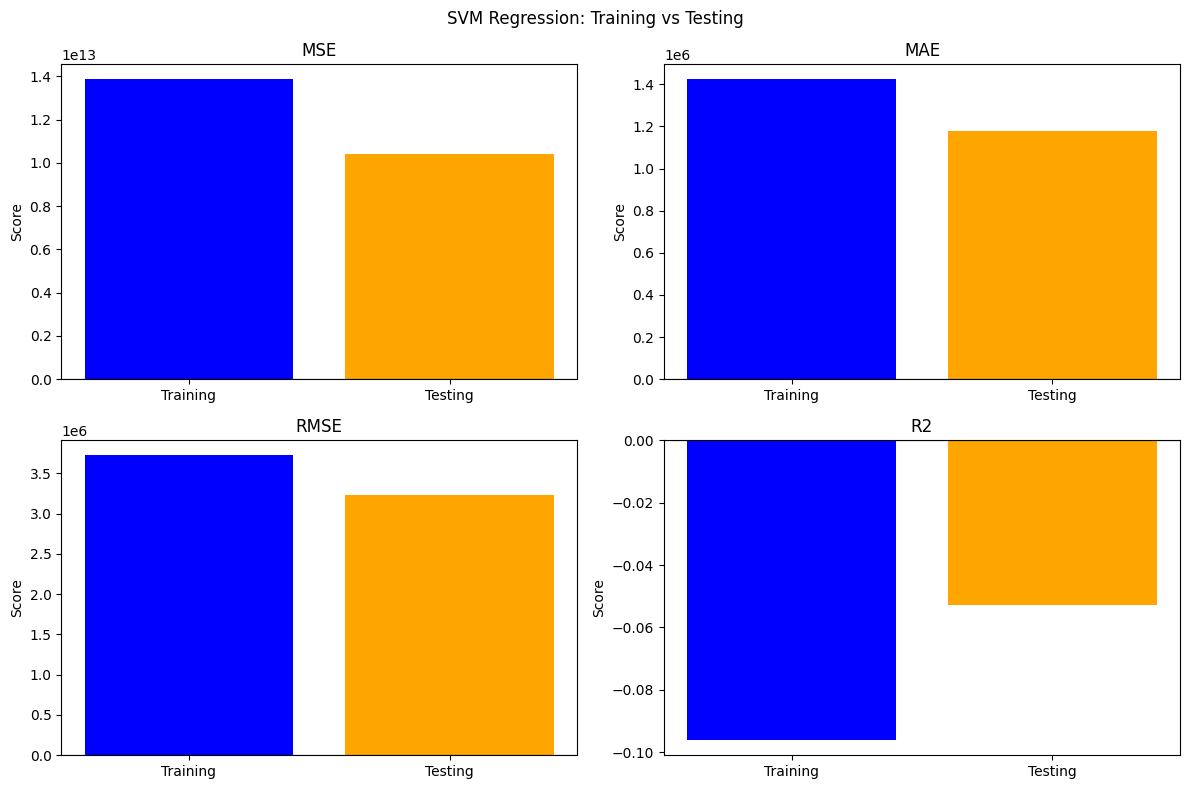

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, svm_results["Metric"]):
    metric_data = svm_melt_results[svm_melt_results["Metric"] == metric]

    ax.bar(
        metric_data["Dataset"],
        metric_data["Score"],
        color = metric_data["Dataset"].map({
            "Training": "blue",
            "Testing": "orange"
        })
    )

    ax.axhline(0, color = "black", linewidth = 0.8)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("SVM Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [14]:
model_package = {
    "model": best_svm_reg_model,
    "hyperparameters": best_params,
    "results": svm_results,
}

joblib.dump(model_package, filename = "../trained_model/svm_reg_model.joblib")

['../trained_model/svm_reg_model.joblib']